In [4]:
import pandas as pd
import numpyro


numpyro.set_host_device_count(8)
numpyro.enable_x64()

In [5]:
df = pd.read_csv("data/cleaned_data.csv").set_index("date")
df.index = pd.to_datetime(df.index)
df

,number,winners,page,pédantix,pedantix,cémantix,cemantix,is_holiday,visitor
date,,,,,,,,,
2022-05-14,1,4398,Affaire Dreyfus,0.0,3.0,8.0,73.0,False,NaN
2022-05-15,2,6632,Nestlé,0.0,6.0,7.0,56.0,False,NaN
2022-05-16,3,9224,Formation et évolution du Système solaire,0.0,6.0,12.0,69.0,False,NaN
2022-05-17,4,13865,Strasbourg,3.0,8.0,12.0,66.0,False,NaN
2022-05-18,5,11130,Processeur,4.0,12.0,12.0,65.0,False,NaN
...,...,...,...,...,...,...,...,...,...
2026-02-12,1371,35355,Information,17.0,23.0,25.0,76.0,False,NaN
2026-02-13,1372,35374,Homme de Néandertal,12.0,17.0,22.0,71.0,False,NaN
2026-02-14,1373,16067,Chamaeleonidae,2.0,4.0,6.0,25.0,False,NaN


,number,winners,page,pédantix,pedantix,cémantix,cemantix,is_holiday,visitor
date,,,,,,,,,
2022-05-14,1,4398,Affaire Dreyfus,0.0,3.0,8.0,73.0,False,NaN
2022-05-15,2,6632,Nestlé,0.0,6.0,7.0,56.0,False,NaN
2022-05-16,3,9224,Formation et évolution du Système solaire,0.0,6.0,12.0,69.0,False,NaN
2022-05-17,4,13865,Strasbourg,3.0,8.0,12.0,66.0,False,NaN
2022-05-18,5,11130,Processeur,4.0,12.0,12.0,65.0,False,NaN
...,...,...,...,...,...,...,...,...,...
2026-02-12,1371,35355,Information,17.0,23.0,25.0,76.0,False,NaN
2026-02-13,1372,35374,Homme de Néandertal,12.0,17.0,22.0,71.0,False,NaN
2026-02-14,1373,16067,Chamaeleonidae,2.0,4.0,6.0,25.0,False,NaN


In [3]:
total_weeks = len(df.resample("W"))
print(f"Total weeks: {total_weeks}")

total_days = len(df)
print(f"Total days: {total_days}")

Total weeks: 198
Total days: 1375


In [6]:
import numpy as np

weekly_hdays = df["is_holiday"].resample("W").sum()
is_hweek = (weekly_hdays > 2)  # your rule: at least 3 holiday-days/week

# run_start is True at the first week of each consecutive holiday block
run_start = is_hweek & ~is_hweek.shift(fill_value=False)

# run_id: 0,1,2,... for holiday weeks, -1 otherwise
holiday_run_id = np.where(is_hweek, run_start.cumsum() - 1, -1).astype(int)

n_holiday_runs = int(run_start.sum())
n_holiday_runs

17

In [10]:
import jax.numpy as jnp
visitor_idx = np.arange(total_days)[~df["visitor"].isna().values]
len(visitor_idx)
obs_pedantix = jnp.asarray(df["pédantix"].values, dtype=jnp.int32)
obs_winners = jnp.asarray(df["winners"].values, dtype=jnp.int32)
obs_visitors = jnp.asarray(df["visitor"].values[visitor_idx], dtype=jnp.int32)
obs_visitors

Array([26957, 30000, 47391, 43913, 44348, 53043, 50435, 38261, 37826,
       49130, 39130, 40000, 41304, 43478, 35652, 31304, 63913, 58261,
       45652, 53043, 63043, 37826, 33043, 53478, 59130, 46957, 51739,
       61304, 43913, 36522, 62609, 59565, 58261, 57826, 64348, 42174,
       33913, 56087, 52609, 58261, 53913, 51739, 41304, 40000, 53043,
       58261, 64783, 63043, 57826, 47391, 38696, 50870, 51304, 48696,
       50435, 48261, 50000, 47826, 46957, 46957, 37826, 40870, 35652,
       39565, 40000, 43913, 43913, 52609, 57391, 49565, 42609, 48696,
       56522, 78696, 53043, 61304, 51304, 43913, 41739, 57391, 63913,
       53913, 52174, 49565, 39565, 36087, 81739, 74348, 56087, 54348,
       54348, 43043], dtype=int32)

In [12]:
from numpyro.infer import MCMC, NUTS, Predictive, init_to_median
from jax import random
import jax.numpy as jnp
import numpyro.distributions as dist
import arviz as az
import jax
from numpyro.infer import AIES, ESS, MCMC, NUTS, SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoMultivariateNormal
from optax import adamw


def logistic(t, norm, start, rate_rise):

    return norm * jax.lax.logistic(rate_rise*(t - start))

def model(observed=True, n=2):

    baseline = numpyro.sample("baseline", dist.Uniform( 0. , +20.))

    norm = numpyro.sample("norm", dist.Uniform( - 10. * jnp.ones(n), +20. * jnp.ones(n)))
    time = numpyro.sample("_time", dist.Uniform( -0.1 * jnp.ones(n), 0.8 * jnp.ones(n)))
    time = jnp.cumsum(time) / (n-1) * total_days
    start = numpyro.deterministic("start", time)
    holidays_factor = numpyro.sample("holidays_factor", dist.Uniform(0., 1.))
    holidays_factor = jnp.where(df["is_holiday"].values, holidays_factor, 1.)

    ### Daily trends
    daily_factor = numpyro.sample("_daily_factor", dist.Uniform(0. * jnp.ones(7) * 0.5, 2 * jnp.ones(7)))
    daily_factor = numpyro.deterministic("daily_factor", daily_factor / daily_factor.mean())
    daily_zeros = numpyro.sample("daily_zeros", dist.Uniform(0. * jnp.ones(7), 1. * jnp.ones(7)))
    daily_factor_flat = daily_factor[df.index.dayofweek.values]
    daily_zeros_flat = daily_zeros[df.index.dayofweek.values]

    ### Monthly trends
    monthly_factors = numpyro.sample("_monthly_factors", dist.Uniform(0. * jnp.ones(12) * 0.5, 2 * jnp.ones(12)))
    monthly_factors = numpyro.deterministic("monthly_factors", monthly_factors / monthly_factors.mean())
    monthly_factors_flat = monthly_factors[df.index.month.values]

    rate_rise = numpyro.sample("rate_rise", dist.TruncatedCauchy(
        0.* jnp.ones(n), 1 * jnp.ones(n),
        low=0., high=5.
    ))

    rises = jax.vmap(lambda t : logistic(t, norm, start, rate_rise))(jnp.arange(total_days)).sum(axis=-1)

    factors = daily_factor_flat * monthly_factors_flat * holidays_factor
    mu = jnp.clip((baseline + rises) * factors , 1e-6, jnp.inf)

    # Overdispersion parameter (phi): smaller -> wider than Poisson, larger -> ~Poisson
    numpyro.sample(
        "obs_pedantix",
        dist.ZeroInflatedPoisson(
                rate=mu, gate=daily_zeros_flat
        ),
        obs=obs_pedantix if observed else None,
    )

    ratio_winners = numpyro.sample("ratio_visitors", dist.LogUniform(1e1, 1e4))
    ratio_visitors = numpyro.sample("ratio_winners", dist.LogUniform(1e1, 1e4))
    phi_winners = numpyro.sample("phi_winners", dist.LogNormal(jnp.log(100.0), 1.0))
    phi_visitors = numpyro.sample("phi_visitors", dist.LogNormal(jnp.log(100.0), 1.0))

    difficulty = numpyro.sample(
        "difficulty",
        dist.Uniform(
            0. * jnp.ones(total_days),
            1. * jnp.ones(total_days)
        )
    )

    mu_winners = mu * ratio_winners * difficulty
    mu_visitors = mu * ratio_visitors

    numpyro.sample(
        "obs_visitors",
        dist.NegativeBinomial2(
            mean=mu_visitors[visitor_idx],
            concentration=phi_visitors
        ),
        obs=obs_visitors if observed else None,
    )

    numpyro.sample(
        "obs_winners",
        dist.NegativeBinomial2(
                mean=mu_winners, concentration=phi_winners
        ),
        obs=obs_winners if observed else None,
    )

mcmc = MCMC(
    NUTS(
        model,
        init_strategy=init_to_median(num_samples=1_000),
        dense_mass=False,
        target_accept_prob=0.8
    ),
    num_chains=8,
    num_warmup=1_000,
    num_samples=1_000
)

rng_key = random.PRNGKey(0)
mcmc.run(rng_key)

posterior_samples = mcmc.get_samples()

posterior_predictive = Predictive(model, posterior_samples)(
    random.PRNGKey(1), observed=False
)

inference_data = az.from_numpyro(
    mcmc,
    posterior_predictive=posterior_predictive
)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [ ]:
"""
optimizer = adamw(learning_rate=3e-4)
guide = AutoMultivariateNormal(model)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

rng_key = random.PRNGKey(0)
keys = random.split(rng_key, 2)
svi_result = svi.run(keys[0], 10_000)
params = svi_result.params

import matplotlib.pyplot as plt
plt.plot(svi_result.losses)
plt.xlabel("Steps")
plt.ylabel("ELBO loss")
plt.semilogy()

predictive = Predictive(guide, params=params, num_samples=10_000)
posterior_samples = predictive(keys[1])
""";

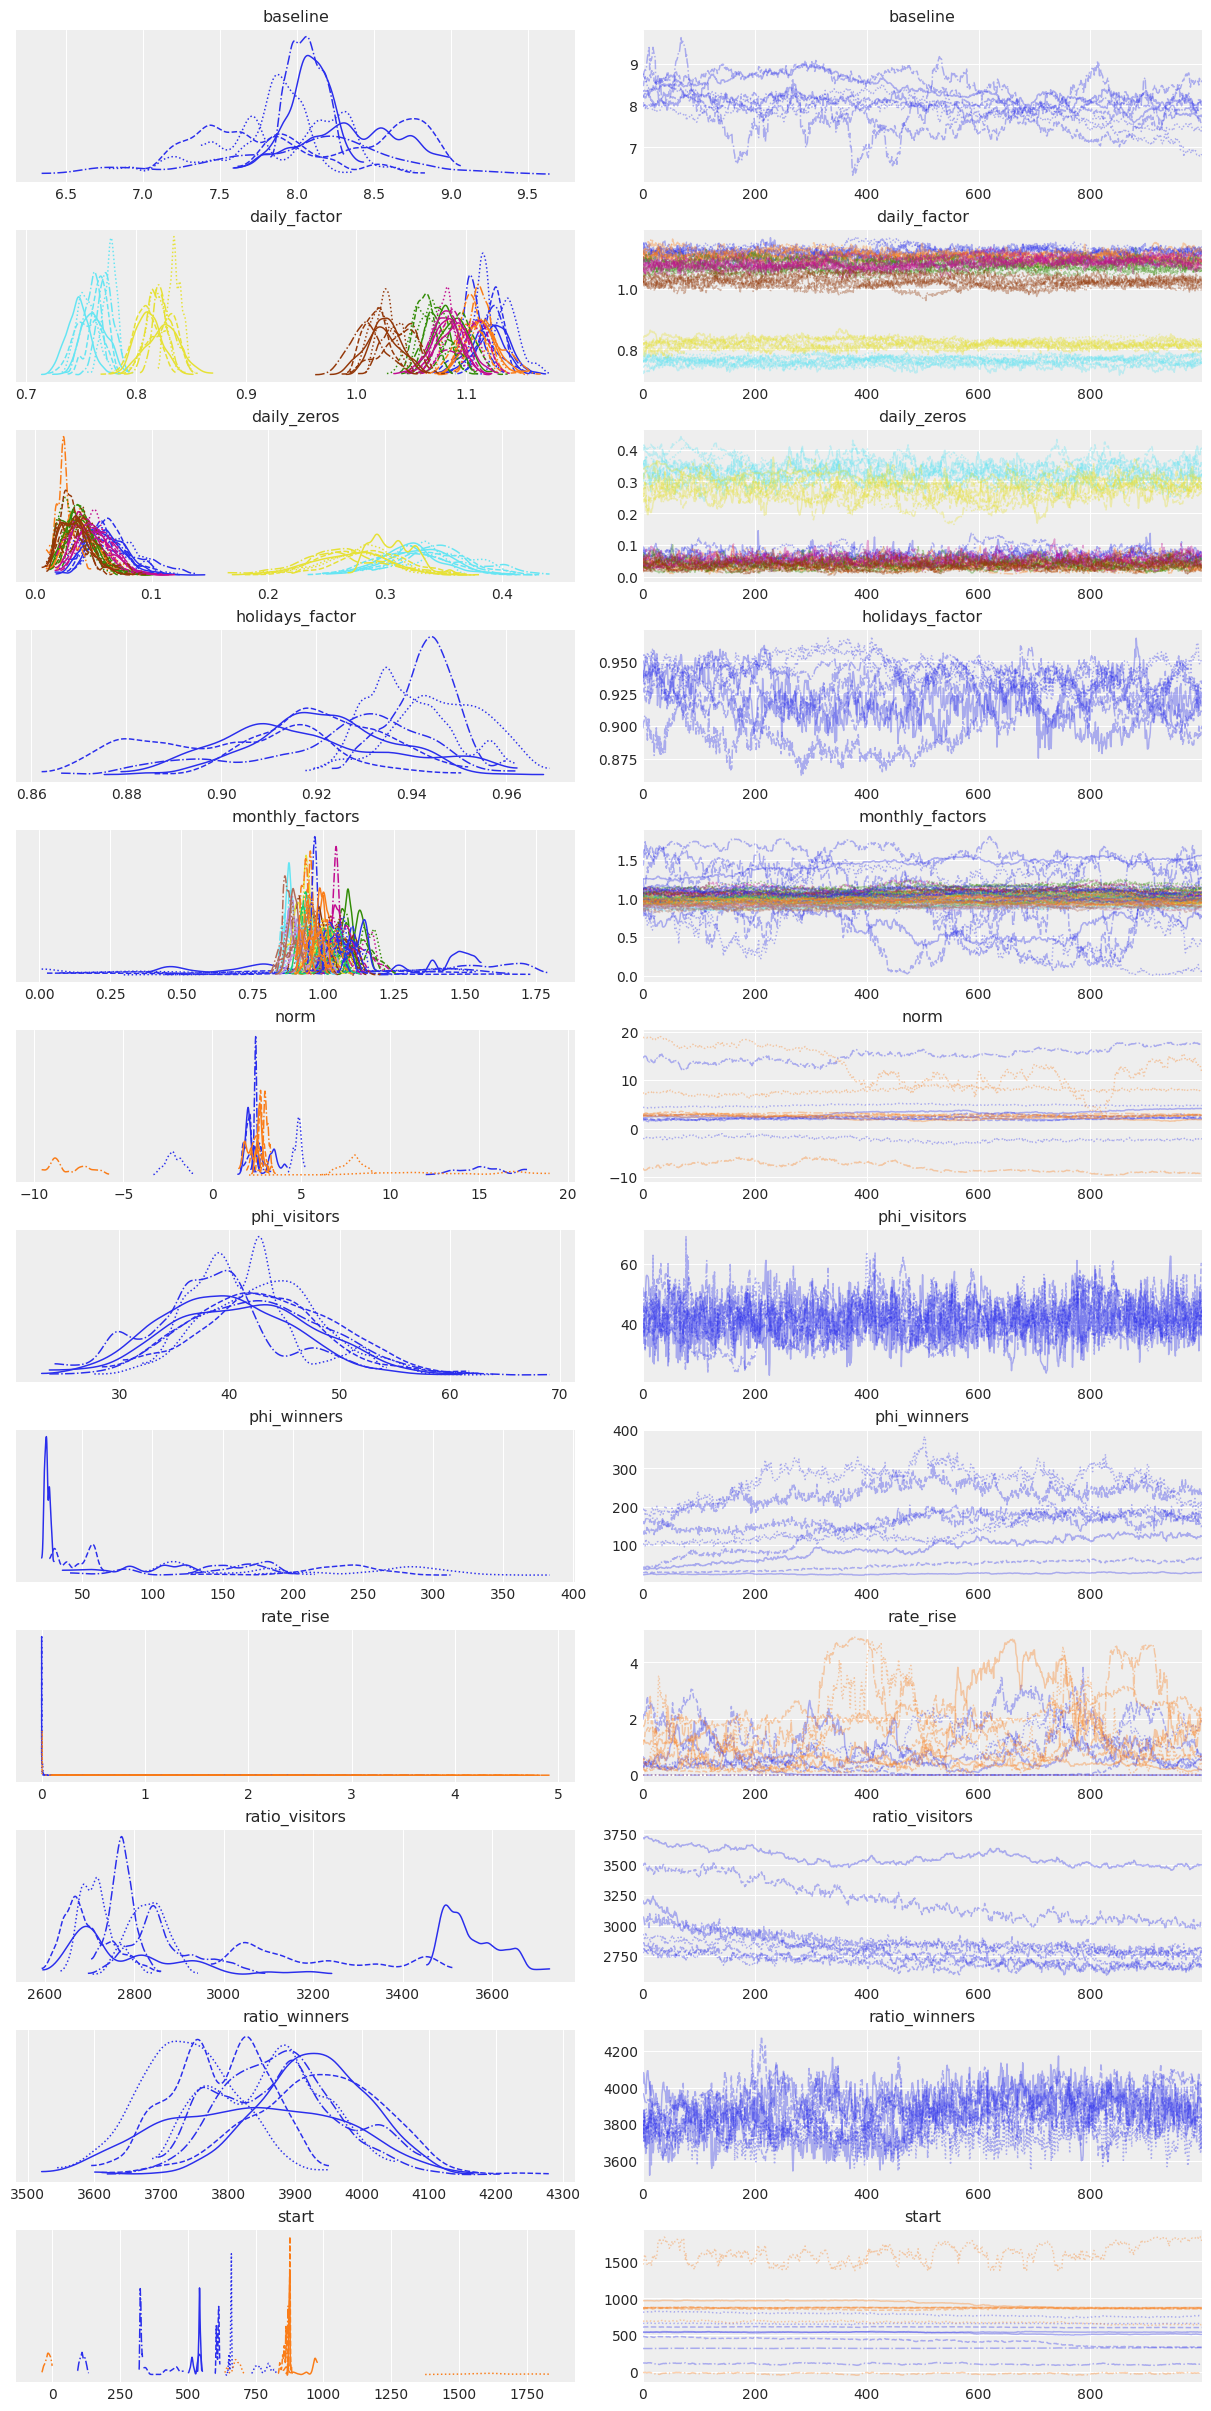

In [19]:
with az.style.context("arviz-darkgrid", after_reset=True):
    az.plot_trace(inference_data, compact=True, var_names=["~^_", "~difficulty"], filter_vars="regex");

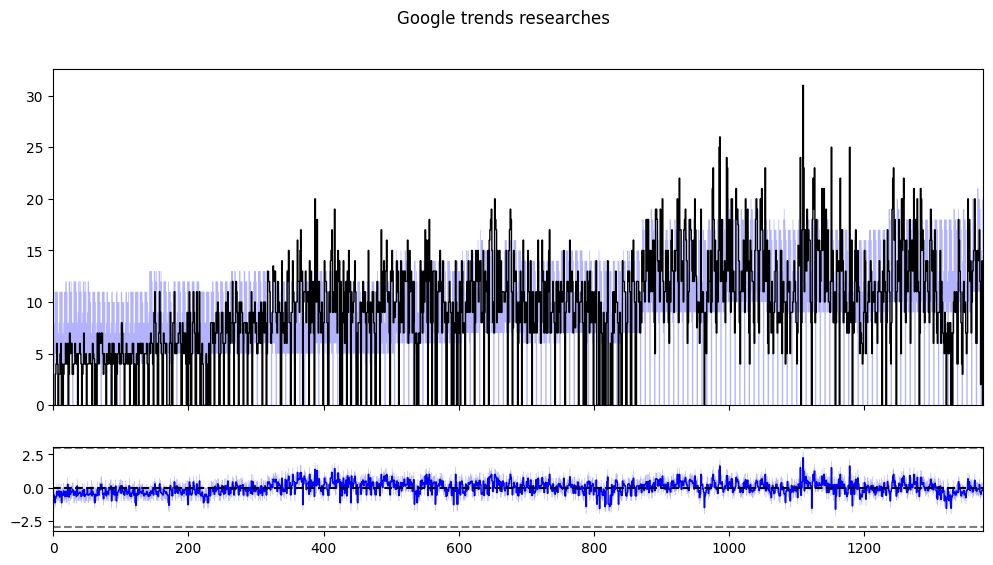

In [20]:
import numpy as np
import matplotlib.pyplot as plt

winners = np.asarray(az.extract(inference_data, "posterior_predictive", var_names=["obs_pedantix"]))
observed_winners = df["pédantix"].values

fig, axs = plt.subplots(nrows=2, figsize=(12, 6), sharex=True, height_ratios=[0.8, 0.2])
axs[0].set_xlim(0, len(observed_winners)+1)

low, up = np.percentile(winners, [14, 86], axis=1)
axs[0].stairs(up, np.arange(len(observed_winners)+1), baseline=low, fill=True, alpha=0.3, color="blue")
axs[0].stairs(observed_winners, np.arange(len(observed_winners)+1), color="black")

low, mid, up = np.percentile(observed_winners[:, None] - winners, [14, 50, 86], axis=1) / (up - low)
axs[1].stairs(
    up,
    np.arange(len(observed_winners)+1),
    baseline=low, fill=True, alpha=0.3, color="blue"
)
axs[1].stairs(
    mid,
    np.arange(len(observed_winners)+1),
    color="blue"
)

axs[1].axhline(0, color="black", linestyle="--")
axs[1].axhline(-3, color="black", linestyle="--", alpha=0.5)
axs[1].axhline(+3, color="black", linestyle="--", alpha=0.5)

plt.suptitle("Google trends researches")
plt.show()

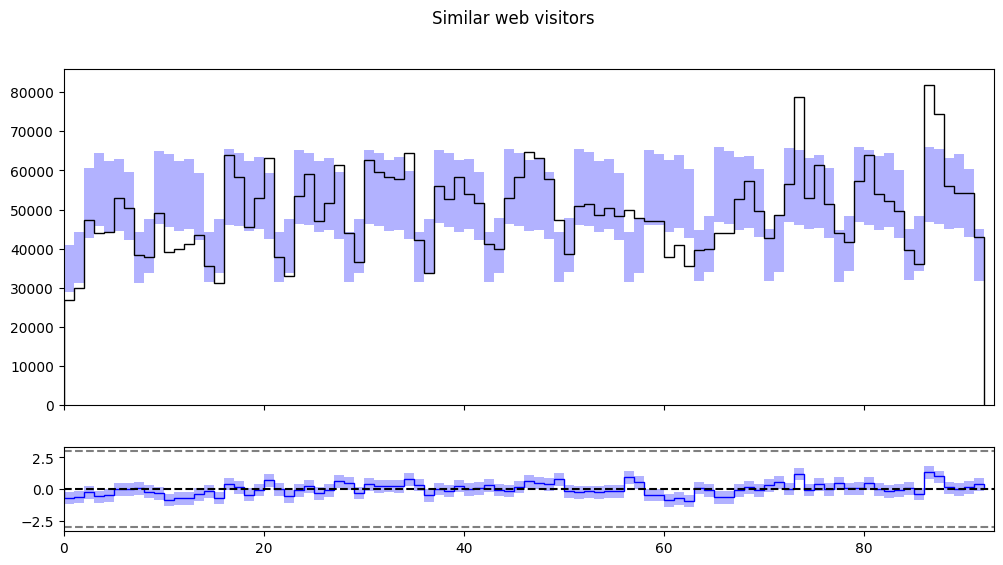

In [21]:
winners = np.asarray(az.extract(inference_data, "posterior_predictive", var_names=["obs_visitors"]))
observed_winners = df["visitor"].values[visitor_idx]

fig, axs = plt.subplots(nrows=2, figsize=(12, 6), sharex=True, height_ratios=[0.8, 0.2])
axs[0].set_xlim(0, len(visitor_idx)+1)

low, up = np.percentile(winners, [14, 86], axis=1)
axs[0].stairs(up, np.arange(len(visitor_idx)+1), baseline=low, fill=True, alpha=0.3, color="blue")
axs[0].stairs(observed_winners, np.arange(len(visitor_idx)+1), color="black")

low, mid, up = np.percentile(observed_winners[:, None] - winners, [14, 50, 86], axis=1) / (up - low)
axs[1].stairs(
    up,
    np.arange(len(visitor_idx)+1),
    baseline=low, fill=True, alpha=0.3, color="blue"
)
axs[1].stairs(
    mid,
    np.arange(len(visitor_idx)+1),
    color="blue"
)

axs[1].axhline(0, color="black", linestyle="--")
axs[1].axhline(-3, color="black", linestyle="--", alpha=0.5)
axs[1].axhline(+3, color="black", linestyle="--", alpha=0.5)

plt.suptitle("Similar web visitors")
plt.show()

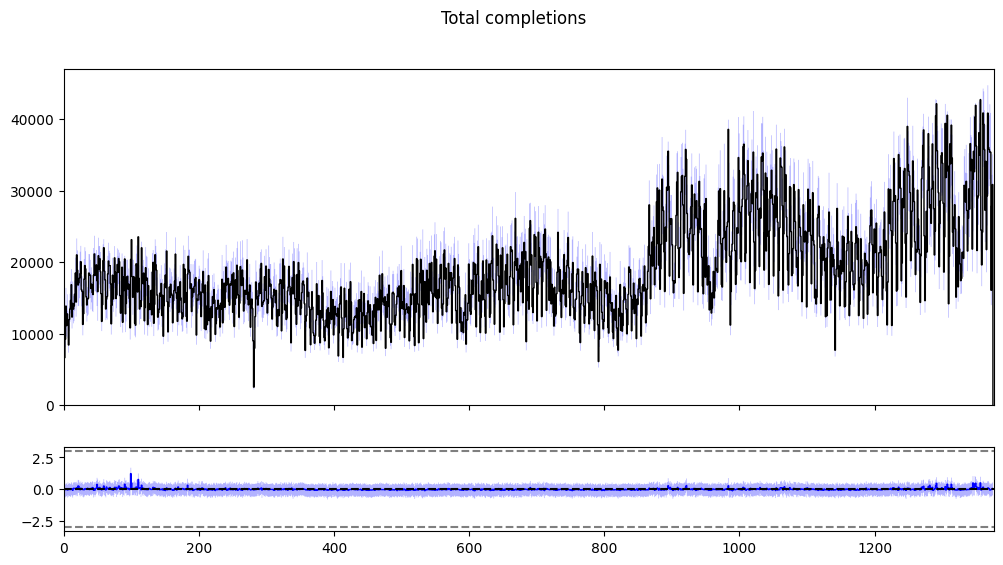

In [22]:
import numpy as np
import matplotlib.pyplot as plt

winners = np.asarray(az.extract(inference_data, "posterior_predictive", var_names=["obs_winners"]))
observed_winners = df["winners"].values

fig, axs = plt.subplots(nrows=2, figsize=(12, 6), sharex=True, height_ratios=[0.8, 0.2])
axs[0].set_xlim(0, len(observed_winners)+1)

low, up = np.percentile(winners, [14, 86], axis=1)
axs[0].stairs(up, np.arange(len(observed_winners)+1), baseline=low, fill=True, alpha=0.3, color="blue")
axs[0].stairs(observed_winners, np.arange(len(observed_winners)+1), color="black")

low, mid, up = np.percentile(observed_winners[:, None] - winners, [14, 50, 86], axis=1) / (up - low)
axs[1].stairs(
    up,
    np.arange(len(observed_winners)+1),
    baseline=low, fill=True, alpha=0.3, color="blue"
)
axs[1].stairs(
    mid,
    np.arange(len(observed_winners)+1),
    color="blue"
)

axs[1].axhline(0, color="black", linestyle="--")
axs[1].axhline(-3, color="black", linestyle="--", alpha=0.5)
axs[1].axhline(+3, color="black", linestyle="--", alpha=0.5)

plt.suptitle("Total completions")
plt.show()

In [31]:
difficulty = np.asarray(az.extract(inference_data, "posterior", var_names=["difficulty"]))
df["difficulty_mean"] = difficulty.mean(axis=1)
df["difficulty_std"] = difficulty.std(axis=1)
df.to_csv("data/dataset_with_difficulty.csv")

In [32]:
df[~df["is_holiday"] & (df["number"] > 30)][["page", "difficulty_mean", "difficulty_std"]].sort_values("difficulty_mean", ascending=False).head(10)

,page,difficulty_mean,difficulty_std
date,,,
2026-01-29,Ours blanc,0.927728,0.071386
2025-11-25,Passage du Nord-Ouest,0.920916,0.086541
2026-01-22,Guerre de Sept Ans,0.918048,0.076451
2022-07-02,Degré Fahrenheit,0.910901,0.099432
2025-11-24,République dominicaine,0.909897,0.090225
2025-11-15,Euro,0.902760,0.091102
2025-12-11,Madrid,0.899655,0.111496
2026-01-18,Guerre de Cent Ans,0.896825,0.109934
2022-11-13,Portugal,0.896721,0.115198


In [33]:
df[~df["is_holiday"] & (df["number"] > 30)].sort_values("difficulty_mean", ascending=True)[["page", "difficulty_mean", "difficulty_std"]].head(10)

,page,difficulty_mean,difficulty_std
date,,,
2024-03-28,Gnosticisme,0.262138,0.039084
2025-06-28,Dynastie Hồng Bàng,0.291653,0.042167
2025-01-24,Modernité comportementale,0.305785,0.040179
2025-06-16,Capétiens,0.312234,0.045314
2024-06-16,Plesiosauria,0.363533,0.047225
2023-07-01,Productivité,0.370633,0.061579
2023-06-24,Assembleur,0.374865,0.054881
2024-05-08,Influence sociale,0.381320,0.053995
2023-06-30,Ghetto,0.383677,0.060963


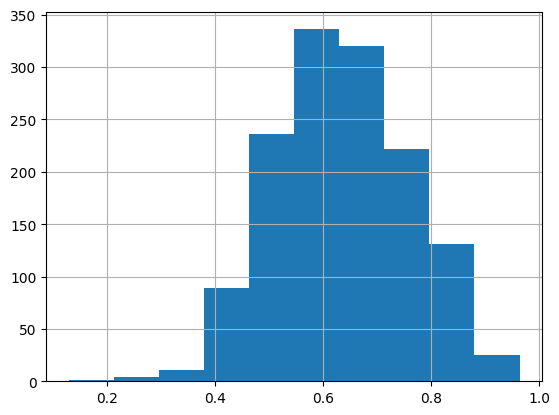

In [37]:
df["difficulty_mean"].hist();

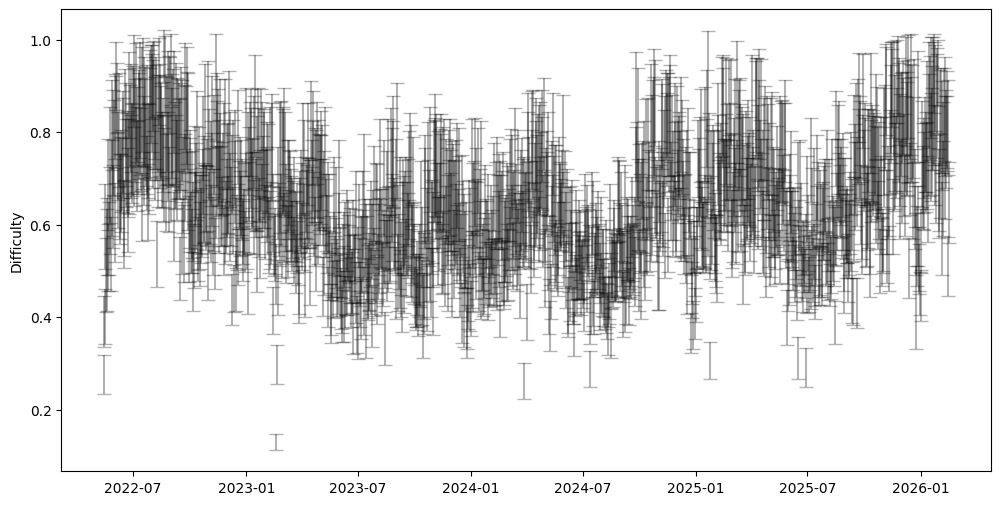

In [36]:
plt.figure(figsize=(12, 6))
plt.errorbar(df.index, 'difficulty_mean', yerr='difficulty_std', data=df, linestyle="none", capsize=5, color="black", alpha=0.3)
plt.ylabel("Difficulty");